In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [ ]:
# ==========================================
# 1. KONFIGURASI PARAMETER (TERKALIBRASI REALISTIS)
# ==========================================
start_date = date(2023, 1, 1)
end_date = date(2045, 12, 31)
days = (end_date - start_date).days + 1

# --- A. Historis Wisatawan & Kapasitas (Overtourism Engine) ---
kapasitas_pengunjung_harian = 2752
lama_tinggal = 3

dom_2023, man_2023 = 355297, 13210
dom_2024, man_2024 = 465751, 19926
dom_2025_est = 390487 * (12 / 9)
man_2025_est = 13300 * (12 / 9)

r_dom_23_24 = (dom_2024 / dom_2023) ** (1 / 365) - 1
r_man_23_24 = (man_2024 / man_2023) ** (1 / 365) - 1
r_dom_24_25 = (dom_2025_est / dom_2024) ** (1 / 365) - 1
r_man_24_25 = (man_2025_est / man_2024) ** (1 / 365) - 1
daily_growth_bau = (1 + 0.0468) ** (1 / 365) - 1

# --- B. Parameter Ekonomi Lokal (PKL) ---
target_pendapatan_layak = 122_778  # UMK Harian
initial_pkl = 200
spending_bau = 75_000

faktor_peningkatan_bau = 0.0005
faktor_kebangkrutan_bau = 0.05
churn_rate_harian_bau = 1 - (1 - faktor_kebangkrutan_bau)**(1/365)

In [ ]:
# ==========================================
# 2. MESIN SIMULASI (CAUSAL LOOP INTEGRATED)
# ==========================================
dates = []
curr_dom_bau, curr_man_bau = dom_2023 / 365, man_2023 / 365
reputasi_bau = 1.0

pkl_bau = initial_pkl
data_pkl_bau = []
data_inc_bau = []

curr_date = start_date

for _ in range(days):
    dates.append(curr_date)
    year = curr_date.year

    if year == 2023:
        g_dom, g_man = r_dom_23_24, r_man_23_24
    elif year == 2024:
        g_dom, g_man = r_dom_24_25, r_man_24_25
    else:
        g_dom, g_man = daily_growth_bau, daily_growth_bau

    pop_today = curr_dom_bau + curr_man_bau
    if pop_today > kapasitas_pengunjung_harian:
        reputasi_bau -= (pop_today / kapasitas_pengunjung_harian - 1.0) * 0.0004
    reputasi_bau = max(0.80, reputasi_bau)

    out_dom, out_man = curr_dom_bau / lama_tinggal, curr_man_bau / lama_tinggal
    in_dom = (out_dom + curr_dom_bau * g_dom) * reputasi_bau
    in_man = (out_man + curr_man_bau * g_man) * reputasi_bau
    curr_dom_bau += (in_dom - out_dom)
    curr_man_bau += (in_man - out_man)
    vis_bau = curr_dom_bau + curr_man_bau

    inc_bau = (vis_bau * spending_bau) / pkl_bau if pkl_bau > 0 else 0

    if inc_bau > target_pendapatan_layak:
        attr_bau = inc_bau / target_pendapatan_layak
        in_bau = pkl_bau * (attr_bau * faktor_peningkatan_bau)
    else:
        in_bau = 0

    out_bau = pkl_bau * churn_rate_harian_bau
    if inc_bau < target_pendapatan_layak:
        out_bau += pkl_bau * ((target_pendapatan_layak - inc_bau) / target_pendapatan_layak) * 0.005

    pkl_bau = max(10, pkl_bau + in_bau - out_bau)

    data_pkl_bau.append(pkl_bau)
    data_inc_bau.append(inc_bau)
    curr_date += timedelta(days=1)

In [ ]:
# ==========================================
# 3. DATAFRAME & VISUAL SMOOTHING
# ==========================================
df = pd.DataFrame({"Date": pd.to_datetime(dates), "PKL": data_pkl_bau, "Income": data_inc_bau})
df["PKL_Smooth"] = df["PKL"].rolling(window=180, min_periods=1, center=True).mean()
df["Income_Smooth"] = df["Income"].rolling(window=180, min_periods=1, center=True).mean()

# Cari titik di mana income turun menembus UMK
cross_fail = df[df["Income_Smooth"] < target_pendapatan_layak].head(1)

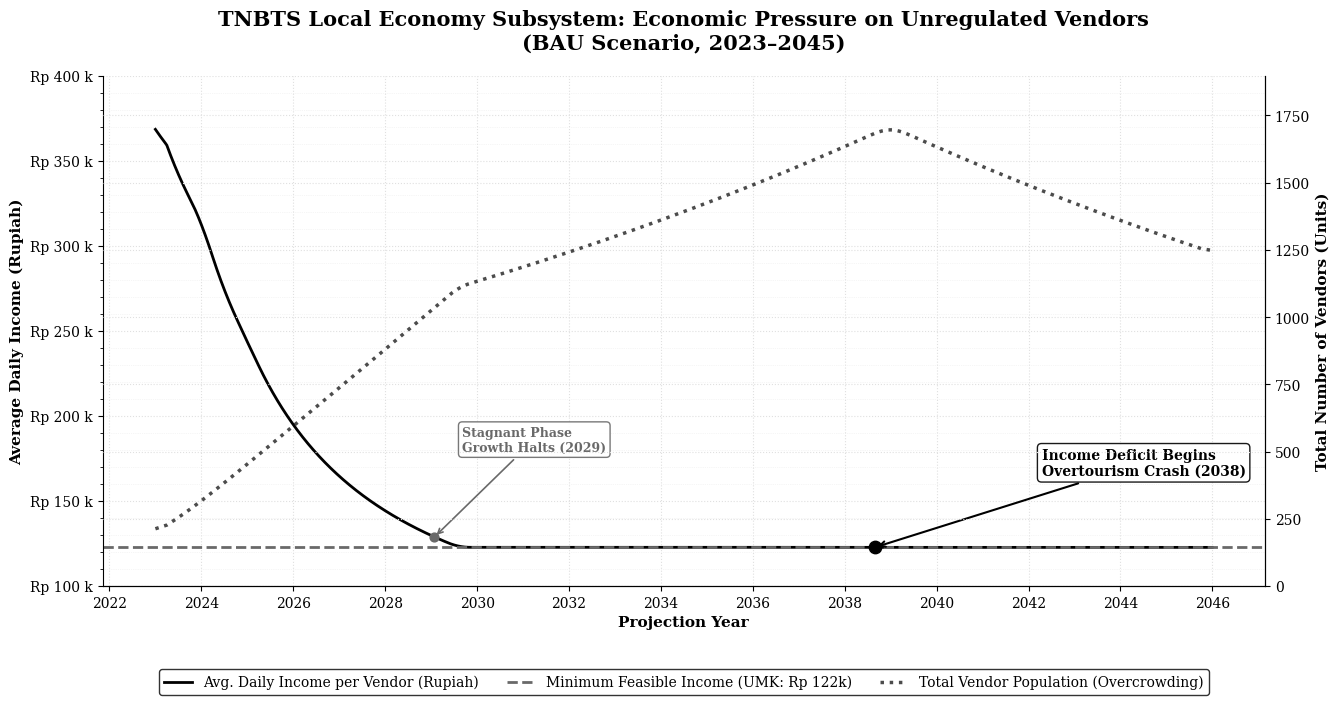

In [ ]:
from matplotlib.ticker import MultipleLocator

# ==========================================
# 4. VISUALISASI MONOKROM AKADEMIS (TWIN AXES - HIGH DETAIL)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif', 'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black',
    'ytick.color': 'black', 'axes.grid': True, 'grid.color': '#e0e0e0',
    'grid.linestyle': ':', 'legend.frameon': True, 'legend.edgecolor': 'black'
})

fig, ax1 = plt.subplots(figsize=(15, 8.5))
plt.subplots_adjust(bottom=0.28)
ax2 = ax1.twinx()

# Plot 1: Rata-rata Pendapatan (Garis DITIPISKAN agar tidak meluber)
line1 = ax1.plot(df["Date"], df["Income_Smooth"], color="black", linestyle="-", linewidth=2.0, label="Avg. Daily Income per Vendor (Rupiah)")
line_umk = ax1.axhline(y=target_pendapatan_layak, color="dimgray", linestyle="--", linewidth=2.0, label=f"Minimum Feasible Income (UMK: Rp {int(target_pendapatan_layak/1000)}k)")

# Plot 2: Populasi PKL
line2 = ax2.plot(df["Date"], df["PKL_Smooth"], color="black", linestyle=":", linewidth=2.5, alpha=0.7, label="Total Vendor Population (Overcrowding)")

# Arsiran Zona Defisit
ax1.fill_between(df["Date"], df["Income_Smooth"], target_pendapatan_layak,
                 where=(df["Income_Smooth"] < target_pendapatan_layak),
                 color="#e0e0e0", alpha=0.7, label="Income Deficit Zone (< UMK)")

# ------------------------------------------
# ANOTASI 1: FASE STAGNAN (Mepet UMK, kisaran 2029)
# ------------------------------------------
cross_stagnant = df[df["Income_Smooth"] <= target_pendapatan_layak * 1.05].head(1)
if not cross_stagnant.empty:
    d_stag = cross_stagnant["Date"].iloc[0]
    val_stag = cross_stagnant["Income_Smooth"].iloc[0]
    ax1.scatter(d_stag, val_stag, color="dimgray", s=40, zorder=5)
    ax1.annotate(
        f"Stagnant Phase\nGrowth Halts ({d_stag.strftime('%Y')})",
        xy=(d_stag, val_stag), xytext=(20, 60), textcoords="offset points",
        fontsize=9, weight='bold', color="dimgray", ha="left", va="bottom",
        arrowprops=dict(arrowstyle="->", color="dimgray", lw=1.2),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="dimgray", alpha=0.9)
    )

# ------------------------------------------
# ANOTASI 2: FASE DEFISIT / KOLAPS (Tembus ke bawah UMK, 2038)
# ------------------------------------------
if not cross_fail.empty:
    d_fail = cross_fail["Date"].iloc[0]
    val_fail = cross_fail["Income_Smooth"].iloc[0]
    ax1.scatter(d_fail, val_fail, color="black", s=80, zorder=6)
    ax1.annotate(
        f"Income Deficit Begins\nOvertourism Crash ({d_fail.strftime('%Y')})",
        xy=(d_fail, val_fail), xytext=(120, 50), textcoords="offset points",
        fontsize=10, weight='bold', ha="left", va="bottom",
        arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9)
    )

# Formatting Judul & Label
ax1.set_title("TNBTS Local Economy Subsystem: Economic Pressure on Unregulated Vendors\n(BAU Scenario, 2023–2045)", fontsize=15, fontweight="bold", pad=20)
ax1.set_xlabel("Projection Year", fontsize=11, fontweight="bold")
ax1.set_ylabel("Average Daily Income (Rupiah)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Total Number of Vendors (Units)", fontsize=11, fontweight="bold")

# ------------------------------------------
# PENAMBAHAN SKALA MINOR (HIGH DETAIL Y-AXIS)
# ------------------------------------------
def format_rupiah(x, pos): return "Rp %1.0f k" % (x * 1e-3)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(format_rupiah))

# Set Major Ticks tiap Rp 50.000, Minor Ticks tiap Rp 10.000
ax1.yaxis.set_major_locator(MultipleLocator(50000))
ax1.yaxis.set_minor_locator(MultipleLocator(10000))

# Nyalakan grid halus untuk Minor Ticks
ax1.grid(which='minor', linestyle=':', linewidth=0.5, color='#e0e0e0', alpha=0.6)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ZOOM-IN Area (Batas bawah dinaikkan ke Rp 100.000)
ax1.set_ylim(bottom=100_000, top=400_000)
max_pkl = df["PKL_Smooth"].max()
ax2.set_ylim(bottom=0, top=max_pkl + 200)

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)

# Legend Gabungan
lines = line1 + [line_umk] + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10, frameon=True, facecolor="white", edgecolor="black")

plt.show()

In [ ]:
# ==========================================
# 5. EKSPOR DATA TAHUNAN
# ==========================================
df["Year"] = df["Date"].dt.year
df_annual = df.groupby("Year").agg(PKL=("PKL_Smooth", "last"), Income=("Income_Smooth", "mean")).reset_index()

print("\n" + "=" * 80)
print("   TABEL PROYEKSI EKONOMI MASYARAKAT TNBTS (SKENARIO BAU TERINTEGRASI)")
print("=" * 80)
print(f"{'Tahun':<6} | {'Total PKL (Unit)':<20} | {'Rerata Pendapatan/Hari':<25} | {'Status'}")
print("-" * 80)

for _, row in df_annual[df_annual["Year"] >= 2024].iterrows():
    year = int(row["Year"])
    pkl = row["PKL"]
    inc = row["Income"]
    status = "LAYAK" if inc >= target_pendapatan_layak else "DEFISIT"
    print(f"{year:<6} | {pkl:>15,.0f} | Rp {inc:>18,.0f} | {status}")
print("=" * 80)


   TABEL PROYEKSI EKONOMI MASYARAKAT TNBTS (SKENARIO BAU TERINTEGRASI)
Tahun  | Total PKL (Unit)     | Rerata Pendapatan/Hari    | Status
--------------------------------------------------------------------------------
2024   |             453 | Rp            276,051 | LAYAK
2025   |             595 | Rp            217,474 | LAYAK
2026   |             737 | Rp            178,768 | LAYAK
2027   |             880 | Rp            153,930 | LAYAK
2028   |           1,024 | Rp            136,698 | LAYAK
2029   |           1,133 | Rp            124,970 | LAYAK
2030   |           1,186 | Rp            122,780 | LAYAK
2031   |           1,242 | Rp            122,780 | LAYAK
2032   |           1,300 | Rp            122,780 | LAYAK
2033   |           1,361 | Rp            122,780 | LAYAK
2034   |           1,424 | Rp            122,780 | LAYAK
2035   |           1,491 | Rp            122,780 | LAYAK
2036   |           1,561 | Rp            122,780 | LAYAK
2037   |           1,634 | Rp          

In [ ]:
# ==========================================
# 6. EVALUASI MAPE: SUBSISTEM EKONOMI LOKAL (PENDAPATAN PKL)
# ==========================================

# 1. Masukkan Data Aktual (Riil) Rata-rata Pendapatan Harian PKL
# CATATAN PENTING: Ganti angka di bawah ini dengan data riil dari lapangan
# (misal: hasil wawancara paguyuban PKL TNBTS atau studi literatur tahun 2023 & 2024).
# Angka di bawah ini adalah estimasi dummy awal (dalam Rupiah).
data_aktual_pkl = {
    2023: 375_000,
    2024: 360_000
}

# Buat DataFrame dari data aktual
df_aktual_pkl = pd.DataFrame(list(data_aktual_pkl.items()), columns=['Year', 'Aktual_Pendapatan'])

# 2. Gabungkan Data Aktual dengan Data Simulasi (df_annual)
# Kita menggunakan kolom 'Income' yang sudah diagregasi rata-rata tahunan di langkah 5
df_eval_pkl = pd.merge(df_aktual_pkl, df_annual, on='Year', how='inner')

# 3. Hitung Absolute Percentage Error (APE) dan MAPE
df_eval_pkl['APE'] = np.abs((df_eval_pkl['Aktual_Pendapatan'] - df_eval_pkl['Income']) / df_eval_pkl['Aktual_Pendapatan']) * 100
mape_pkl = df_eval_pkl['APE'].mean()

# 4. Tampilkan Hasil Evaluasi Ekonomi Lokal (PKL)
print("\n" + "="*80)
print("     EVALUASI MAPE: SUBSISTEM EKONOMI LOKAL (PENDAPATAN HARIAN PKL)")
print("="*80)
print(df_eval_pkl[['Year', 'Aktual_Pendapatan', 'Income', 'APE']].rename(
    columns={'Aktual_Pendapatan': 'Aktual (Rupiah)', 'Income': 'Simulasi (Rupiah)', 'APE': 'Error (%)'}
).round(2).to_string(index=False))
print("-" * 80)
print(f"NILAI MAPE SUBSISTEM EKONOMI LOKAL : {mape_pkl:.2f}%")

# Kategorisasi standar akurasi
if mape_pkl < 10:
    kategori_pkl = "Sangat Akurat (Highly Accurate)"
elif mape_pkl < 20:
    kategori_pkl = "Baik (Good)"
elif mape_pkl < 50:
    kategori_pkl = "Cukup (Reasonable)"
else:
    kategori_pkl = "Kurang Akurat (Inaccurate)"

print(f"KATEGORI AKURASI                   : {kategori_pkl}")
print("=" * 80)


     EVALUASI MAPE: SUBSISTEM EKONOMI LOKAL (PENDAPATAN HARIAN PKL)
 Year  Aktual (Rupiah)  Simulasi (Rupiah)  Error (%)
 2023           375000          342570.44       8.65
 2024           360000          276051.31      23.32
--------------------------------------------------------------------------------
NILAI MAPE SUBSISTEM EKONOMI LOKAL : 15.98%
KATEGORI AKURASI                   : Baik (Good)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

In [ ]:
# ==========================================
# 1. KONFIGURASI PARAMETER (TERKALIBRASI REALISTIS)
# ==========================================
start_date = date(2023, 1, 1)
end_date = date(2045, 12, 31)
days = (end_date - start_date).days + 1

# --- A. Historis Wisatawan & Kapasitas ---
kapasitas_pengunjung_harian = 2752
lama_tinggal = 3

dom_2023, man_2023 = 355297, 13210
dom_2024, man_2024 = 465751, 19926
dom_2025_est = 390487 * (12 / 9)
man_2025_est = 13300 * (12 / 9)

r_dom_23_24 = (dom_2024 / dom_2023) ** (1 / 365) - 1
r_man_23_24 = (man_2024 / man_2023) ** (1 / 365) - 1
r_dom_24_25 = (dom_2025_est / dom_2024) ** (1 / 365) - 1
r_man_24_25 = (man_2025_est / man_2024) ** (1 / 365) - 1
daily_growth_bau = (1 + 0.0468) ** (1 / 365) - 1

# --- B. Intervensi Harga (Menstabilkan Turis) ---
elasticity = -0.504
price_dom_old = ((5 * 54000) + (2 * 79000)) / 7
price_man_old = 255000
price_dom_new = ((5 * 58320) + (2 * 90850)) / 7
price_man_new = 318750
shock_dom = ((price_dom_new - price_dom_old) / price_dom_old) * elasticity
shock_man = ((price_man_new - price_man_old) / price_man_old) * elasticity
daily_growth_int = (1 + 0.035) ** (1 / 365) - 1

# --- C. Parameter Ekonomi Lokal (BAU vs INTERVENSI) ---
target_pendapatan_layak = 122_778
initial_pkl = 200
faktor_peningkatan_bau = 0.0005
churn_rate_harian_bau = 1 - (1 - 0.05)**(1/365)

# Spending dibuat SAMA untuk BAU dan Intervensi (Rp 75.000)
spending_turis = 75_000

# INTERVENSI: Hanya membatasi kuota izin usaha
kuota_maksimal_pkl = 450

In [ ]:
# ==========================================
# 2. MESIN SIMULASI (CAUSAL LOOP INTEGRATED)
# ==========================================
dates = []
curr_dom_bau, curr_man_bau = dom_2023 / 365, man_2023 / 365
curr_dom_int, curr_man_int = dom_2023 / 365, man_2023 / 365
reputasi_bau, reputasi_int = 1.0, 1.0

pkl_bau, pkl_int = initial_pkl, initial_pkl
data_pkl_bau, data_inc_bau = [], []
data_pkl_int, data_inc_int = [], []

curr_date = start_date

for _ in range(days):
    dates.append(curr_date)
    year = curr_date.year

    # --- MODUL WISATAWAN ---
    if year == 2023:
        g_dom_bau, g_man_bau = r_dom_23_24, r_man_23_24
        g_dom_int, g_man_int = r_dom_23_24, r_man_23_24
    elif year == 2024:
        g_dom_bau, g_man_bau = r_dom_24_25, r_man_24_25
        g_dom_int, g_man_int = r_dom_24_25, r_man_24_25
    else:
        g_dom_bau, g_man_bau = daily_growth_bau, daily_growth_bau
        if year == 2026 and curr_date == date(2026, 1, 1):
            curr_dom_int *= (1 + shock_dom)
            curr_man_int *= (1 + shock_man)
        elif year >= 2026:
            g_dom_int, g_man_int = daily_growth_int, daily_growth_int
        else:
            g_dom_int, g_man_int = daily_growth_bau, daily_growth_bau

    pop_bau = curr_dom_bau + curr_man_bau
    if pop_bau > kapasitas_pengunjung_harian:
        reputasi_bau -= (pop_bau / kapasitas_pengunjung_harian - 1.0) * 0.0004
    reputasi_bau = max(0.80, reputasi_bau)

    pop_int = curr_dom_int + curr_man_int
    if pop_int > kapasitas_pengunjung_harian:
        reputasi_int -= (pop_int / kapasitas_pengunjung_harian - 1.0) * 0.0004
    reputasi_int = max(0.80, reputasi_int)

    out_bau_dom, out_bau_man = curr_dom_bau / lama_tinggal, curr_man_bau / lama_tinggal
    in_bau_dom = (out_bau_dom + curr_dom_bau * g_dom_bau) * reputasi_bau
    in_bau_man = (out_bau_man + curr_man_bau * g_man_bau) * reputasi_bau
    curr_dom_bau += (in_bau_dom - out_bau_dom)
    curr_man_bau += (in_bau_man - out_bau_man)
    vis_bau = curr_dom_bau + curr_man_bau

    out_int_dom, out_int_man = curr_dom_int / lama_tinggal, curr_man_int / lama_tinggal
    if year >= 2026:
        in_int_dom = (out_int_dom + curr_dom_int * g_dom_int) * reputasi_int
        in_int_man = (out_int_man + curr_man_int * g_man_int) * reputasi_int
    else:
        in_int_dom = (out_int_dom + curr_dom_int * g_dom_bau) * reputasi_int
        in_int_man = (out_int_man + curr_man_int * g_man_bau) * reputasi_int
    curr_dom_int += (in_int_dom - out_int_dom)
    curr_man_int += (in_int_man - out_int_man)
    vis_int = curr_dom_int + curr_man_int

    # --- MODUL EKONOMI LOKAL (BAU) ---
    inc_bau = (vis_bau * spending_turis) / pkl_bau if pkl_bau > 0 else 0
    if inc_bau > target_pendapatan_layak:
        attr_bau = inc_bau / target_pendapatan_layak
        in_bau_pkl = pkl_bau * (attr_bau * faktor_peningkatan_bau)
    else:
        in_bau_pkl = 0

    out_bau_pkl = pkl_bau * churn_rate_harian_bau
    if inc_bau < target_pendapatan_layak:
        out_bau_pkl += pkl_bau * ((target_pendapatan_layak - inc_bau) / target_pendapatan_layak) * 0.005
    pkl_bau = max(10, pkl_bau + in_bau_pkl - out_bau_pkl)

    # --- MODUL EKONOMI LOKAL (INTERVENSI) ---
    inc_int = (vis_int * spending_turis) / pkl_int if pkl_int > 0 else 0

    if inc_int > target_pendapatan_layak:
        attr_int = inc_int / target_pendapatan_layak
        in_int_pkl = pkl_int * (attr_int * faktor_peningkatan_bau)
    else:
        in_int_pkl = 0

    out_int_pkl = pkl_int * churn_rate_harian_bau

    # EKSEKUSI KEBIJAKAN: Kunci maksimal jumlah PKL di angka 450 (Mulai 2026)
    if year >= 2026:
        pkl_int = min(kuota_maksimal_pkl, max(10, pkl_int + in_int_pkl - out_int_pkl))
    else:
        pkl_int = max(10, pkl_int + in_int_pkl - out_int_pkl)

    data_pkl_bau.append(pkl_bau); data_inc_bau.append(inc_bau)
    data_pkl_int.append(pkl_int); data_inc_int.append(inc_int)
    curr_date += timedelta(days=1)

In [ ]:
# ==========================================
# 3. DATAFRAME & VISUAL SMOOTHING
# ==========================================
df = pd.DataFrame({"Date": pd.to_datetime(dates),
                   "PKL_BAU": data_pkl_bau, "Inc_BAU": data_inc_bau,
                   "PKL_INT": data_pkl_int, "Inc_INT": data_inc_int})

for col in ["PKL_BAU", "Inc_BAU", "PKL_INT", "Inc_INT"]:
    df[col+"_Smooth"] = df[col].rolling(window=180, min_periods=1, center=True).mean()

cross_fail = df[df["Inc_BAU_Smooth"] < target_pendapatan_layak].head(1)

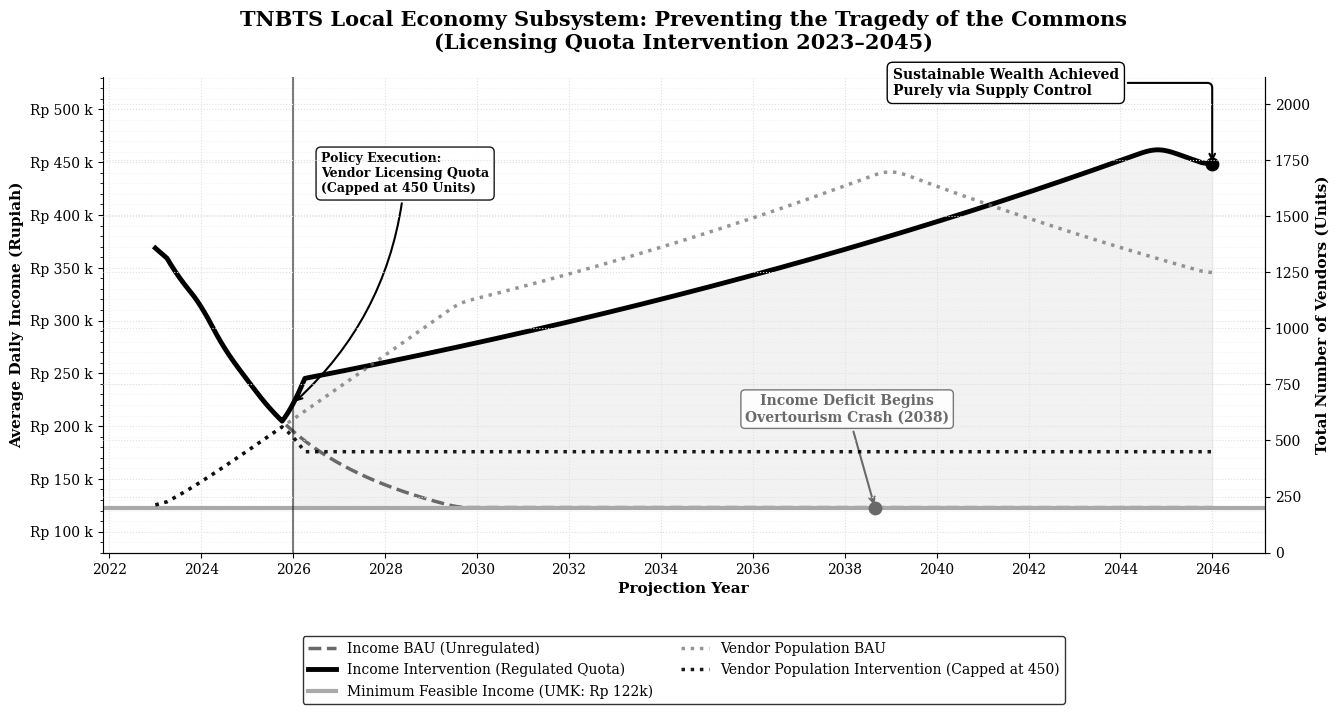

In [ ]:
# ==========================================
# 4. VISUALISASI MONOKROM AKADEMIS (AUTO-SCALING & ANTI KEPOTONG)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif', 'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black',
    'ytick.color': 'black', 'axes.grid': True, 'grid.color': '#e0e0e0',
    'grid.linestyle': ':', 'legend.frameon': True, 'legend.edgecolor': 'black'
})

fig, ax1 = plt.subplots(figsize=(15, 8.5))
plt.subplots_adjust(bottom=0.32)
ax2 = ax1.twinx()

# --- PLOT PENDAPATAN (AXIS 1) ---
line_inc_bau = ax1.plot(df["Date"], df["Inc_BAU_Smooth"], color="dimgray", linestyle="--", linewidth=2.5, label="Income BAU (Unregulated)")
line_inc_int = ax1.plot(df["Date"], df["Inc_INT_Smooth"], color="black", linestyle="-", linewidth=3.5, label="Income Intervention (Regulated Quota)")
line_umk = ax1.axhline(y=target_pendapatan_layak, color="darkgray", linestyle="-", linewidth=3, label=f"Minimum Feasible Income (UMK: Rp {int(target_pendapatan_layak/1000)}k)")

# --- PLOT POPULASI PKL (AXIS 2) ---
line_pkl_bau = ax2.plot(df["Date"], df["PKL_BAU_Smooth"], color="dimgray", linestyle=":", linewidth=2.5, alpha=0.7, label="Vendor Population BAU")
line_pkl_int = ax2.plot(df["Date"], df["PKL_INT_Smooth"], color="black", linestyle=":", linewidth=2.5, alpha=0.9, label=f"Vendor Population Intervention (Capped at {kuota_maksimal_pkl})")

df_shaded = df[df["Date"] >= pd.Timestamp("2026-01-01")]
ax1.fill_between(df_shaded["Date"], df_shaded["Inc_INT_Smooth"], target_pendapatan_layak,
                 where=(df_shaded["Inc_INT_Smooth"] >= target_pendapatan_layak),
                 color="#e0e0e0", alpha=0.4, label="Prosperity Margin (Income > UMK)")

# ------------------------------------------
# ANOTASI
# ------------------------------------------
batas_intervensi = pd.Timestamp("2026-01-01")
val_2026 = df.loc[df["Date"] == batas_intervensi, "Inc_INT_Smooth"].values[0]

ax1.axvline(x=batas_intervensi, color="black", linestyle="-", linewidth=1.5, alpha=0.5)
ax1.annotate(
    "Policy Execution:\nVendor Licensing Quota\n(Capped at 450 Units)",
    xy=(batas_intervensi, val_2026),
    xytext=(20, 150), textcoords="offset points",
    fontsize=9, weight='bold', ha="left", va="bottom",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5, connectionstyle="arc3,rad=-0.2"),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.9)
)

if not cross_fail.empty:
    d_fail = cross_fail["Date"].iloc[0]
    val_fail = cross_fail["Inc_BAU_Smooth"].iloc[0]
    ax1.scatter(d_fail, val_fail, color="dimgray", s=80, zorder=5)
    ax1.annotate(
        f"Income Deficit Begins\nOvertourism Crash ({d_fail.strftime('%Y')})",
        xy=(d_fail, val_fail),
        xytext=(-20, 60), textcoords="offset points",
        fontsize=10, weight='bold', color="dimgray", ha="center", va="bottom",
        arrowprops=dict(arrowstyle="->", color="dimgray", lw=1.5),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="dimgray", alpha=0.9)
    )

end_date = df["Date"].iloc[-1]
end_val_int = df["Inc_INT_Smooth"].iloc[-1]

ax1.scatter(end_date, end_val_int, color="black", s=80, zorder=6)
ax1.annotate(
    "Sustainable Wealth Achieved\nPurely via Supply Control",
    xy=(end_date, end_val_int),
    xytext=(-230, 50), textcoords="offset points", # Teks ini saya tarik sedikit ke bawah agar tidak keluar dari frame kanan atas
    fontsize=10, weight='bold', color='black',
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5, connectionstyle="angle,angleA=0,angleB=90,rad=5"),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=1.0)
)

# ------------------------------------------
# FORMATTING SUMBU & AUTO SCALING DINAMIS
# ------------------------------------------
ax1.set_title("TNBTS Local Economy Subsystem: Preventing the Tragedy of the Commons\n(Licensing Quota Intervention 2023–2045)", fontsize=15, fontweight="bold", pad=20)
ax1.set_xlabel("Projection Year", fontsize=11, fontweight="bold")
ax1.set_ylabel("Average Daily Income (Rupiah)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Total Number of Vendors (Units)", fontsize=11, fontweight="bold")

def format_rupiah(x, pos): return "Rp %1.0f k" % (x * 1e-3)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(format_rupiah))

ax1.yaxis.set_major_locator(MultipleLocator(50000))
ax1.yaxis.set_minor_locator(MultipleLocator(10000))
ax1.grid(which='minor', linestyle=':', linewidth=0.5, color='#e0e0e0', alpha=0.6)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# SETTING AUTO-SCALING ANTI KEPOTONG
max_income_data = max(df["Inc_BAU_Smooth"].max(), df["Inc_INT_Smooth"].max())
ax1.set_ylim(bottom=80_000, top=max_income_data * 1.15) # Atap Sumbu Kiri otomatis ditambah 15% dari data tertinggi

max_pkl_data = max(df["PKL_BAU_Smooth"].max(), df["PKL_INT_Smooth"].max())
ax2.set_ylim(bottom=0, top=max_pkl_data * 1.25) # Atap Sumbu Kanan otomatis ditambah 25% dari data tertinggi

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)

lines = line_inc_bau + line_inc_int + [line_umk] + line_pkl_bau + line_pkl_int
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=2, fontsize=10, frameon=True, facecolor="white", edgecolor="black")

plt.show()

In [ ]:
# ==========================================
# 5. EKSPOR DATA TAHUNAN
# ==========================================
df["Year"] = df["Date"].dt.year
df_annual = df.groupby("Year").agg(
    PKL_BAU=("PKL_BAU_Smooth", "last"), Income_BAU=("Inc_BAU_Smooth", "mean"),
    PKL_INT=("PKL_INT_Smooth", "last"), Income_INT=("Inc_INT_Smooth", "mean")
).reset_index()

print("\n" + "=" * 100)
print("   TABEL PERBANDINGAN EKONOMI LOKAL TNBTS (BAU vs INTERVENSI ZONASI)")
print("=" * 100)
print(f"{'Tahun':<6} | {'Pendapatan BAU':<18} | {'Pendapatan Intervensi':<25} | {'Populasi PKL (INT)'}")
print("-" * 100)

for _, row in df_annual[df_annual["Year"] >= 2024].iterrows():
    year = int(row["Year"])
    i_bau = row["Income_BAU"]
    i_int = row["Income_INT"]
    p_int = row["PKL_INT"]

    status_bau = "(DEFISIT)" if i_bau < target_pendapatan_layak else ""

    print(f"{year:<6} | Rp {i_bau:>7,.0f} {status_bau:<9} | Rp {i_int:>7,.0f} (PROSPER)       | {p_int:>4,.0f} Unit (Terkunci)")
print("=" * 100)


   TABEL PERBANDINGAN EKONOMI LOKAL TNBTS (BAU vs INTERVENSI ZONASI)
Tahun  | Pendapatan BAU     | Pendapatan Intervensi     | Populasi PKL (INT)
----------------------------------------------------------------------------------------------------
2024   | Rp 276,051           | Rp 276,051 (PROSPER)       |  453 Unit (Terkunci)
2025   | Rp 217,474           | Rp 220,562 (PROSPER)       |  514 Unit (Terkunci)
2026   | Rp 178,768           | Rp 244,457 (PROSPER)       |  450 Unit (Terkunci)
2027   | Rp 153,930           | Rp 255,964 (PROSPER)       |  450 Unit (Terkunci)
2028   | Rp 136,698           | Rp 264,935 (PROSPER)       |  450 Unit (Terkunci)
2029   | Rp 124,970           | Rp 274,221 (PROSPER)       |  450 Unit (Terkunci)
2030   | Rp 122,780           | Rp 283,818 (PROSPER)       |  450 Unit (Terkunci)
2031   | Rp 122,780           | Rp 293,752 (PROSPER)       |  450 Unit (Terkunci)
2032   | Rp 122,780           | Rp 304,048 (PROSPER)       |  450 Unit (Terkunci)
2033   | Rp 12